In [ ]:

import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns


import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize


from sklearn.model_selection import train_test_split


import warnings
warnings.filterwarnings('ignore')

nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
# Load datasets
train_df = pd.read_csv("C:/Users/anmnu/DSML/Week7/Project/Project Info/dataset/training_data.csv", delimiter = "\t", header = None)
test_df = pd.read_csv("C:/Users/anmnu/DSML/Week7/Project/Project Info/dataset/testing_data.csv" , delimiter = "\t", header = None)
print("Training Dataset Shape:", train_df.shape)
print("Testing Dataset Shape:", test_df.shape)

Training Dataset Shape: (34152, 2)
Testing Dataset Shape: (9984, 2)


In [ ]:
train_df.head()

,0,1
0,0,donald trump sends out embarrassing new year‚s...
1,0,drunk bragging trump staffer started russian c...
2,0,sheriff david clarke becomes an internet joke ...
3,0,trump is so obsessed he even has obama‚s name ...
4,0,pope francis just called out donald trump duri...


In [ ]:
# Renamed the columns as label and text
train_df.columns = ['label', 'text']
test_df.columns = ['label', 'text']

test_df

,label,text
0,2,copycat muslim terrorist arrested with assault...
1,2,wow! chicago protester caught on camera admits...
2,2,germany's fdp look to fill schaeuble's big shoes
3,2,mi school sends welcome back packet warning ki...
4,2,u.n. seeks 'massive' aid boost amid rohingya '...
...,...,...
9979,2,boom! fox news leftist chris wallace attempts ...
9980,2,here it is: list of democrat hypocrites who vo...
9981,2,new fires ravage rohingya villages in northwes...
9982,2,meals on wheels shuts the lyin‚ lefties up wit...


In [ ]:
train_df

,label,text
0,0,donald trump sends out embarrassing new year‚s...
1,0,drunk bragging trump staffer started russian c...
2,0,sheriff david clarke becomes an internet joke ...
3,0,trump is so obsessed he even has obama‚s name ...
4,0,pope francis just called out donald trump duri...
...,...,...
34147,1,tears in rain as thais gather for late king's ...
34148,1,pyongyang university needs non-u.s. teachers a...
34149,1,philippine president duterte to visit japan ah...
34150,1,japan's abe may have won election\tbut many do...


In [ ]:
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# CHECK DATASET INFO
print("\nTraining Dataset Info:\n")
train_df.info()

# CHECK MISSING VALUES
print("\nMissing Values in Training Dataset:\n")
print(train_df.isnull().sum())
print("\nMissing Values in Testing Dataset:\n")
print(test_df.isnull().sum())


Training Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34152 entries, 0 to 34151
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   34152 non-null  int64 
 1   text    34152 non-null  object
dtypes: int64(1), object(1)
memory usage: 533.8+ KB

Missing Values in Training Dataset:

label    0
text     0
dtype: int64

Missing Values in Testing Dataset:

label    0
text     0
dtype: int64


In [ ]:
# CHECK DUPLICATES
print("\nDuplicate Rows in Training Dataset:", train_df.duplicated().sum())
print("Duplicate Rows in Testing Dataset:", test_df.duplicated().sum())


Duplicate Rows in Training Dataset: 1946
Duplicate Rows in Testing Dataset: 775


In [ ]:
# REMOVE DUPLICATES (OPTIONAL)
train_df.drop_duplicates(inplace=True)
test_df.drop_duplicates(inplace=True)
print("\nShape After Removing Duplicates:")
print("Training:", train_df.shape)
print("Testing:", test_df.shape)


Shape After Removing Duplicates:
Training: (32206, 2)
Testing: (9209, 2)


## Data Cleaning

In [ ]:
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

In [ ]:
def clean_text(text):

    # lowercase
    text = text.lower()

    # remove punctuation
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)

    # remove numbers
    text = re.sub(r'\d+', '', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text)

    # tokenize
    words = text.split()

    # remove stopwords + lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [ ]:
import nltk
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\anmnu\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
train_df['text'] = train_df['text'].apply(clean_text)

In [ ]:
test_df['text'] = test_df['text'].apply(clean_text)

In [ ]:
train_df.head()

NameError: name 'train_df' is not defined

In [ ]:
test_df.head()

,label,text
0,2,copycat muslim terrorist arrested assault weapon
1,2,wow chicago protester caught camera admits vio...
2,2,germany fdp look fill schaeuble big shoe
3,2,mi school sends welcome back packet warning ki...
4,2,u n seek massive aid boost amid rohingya emerg...


In [ ]:
## Test-train split

from sklearn.model_selection import train_test_split

train_df_train, train_df_val = train_test_split(train_df, test_size = 0.2, random_state = 42, stratify = train_df['label'])

In [ ]:
train_df_train

,label,text
25297,1,clinton think regulator scrutinize time warner...
453,0,suspicious smoke billowing closing russian con...
885,0,trump jr ‚s latest move prof russia investigat...
11091,0,flashback video show leftist medium member pra...
5134,0,nevertrump gopers demand emergency rnc meeting...
...,...,...
20703,1,house speaker optimistic tax reform prospect y...
31238,1,exclusive colleague name putin daughter withdr...
5751,0,trump scotland collapse united kingdom great g...
18314,1,house panel drop effort force testimony trump ...


In [ ]:
train_df_val

,label,text
31563,1,debate stifled cambodia crackdown spread fear
19082,1,u senator announce deal self driving car legis...
17721,1,republican house speaker ryan told trump retir...
10160,0,watch trump supporter crash pro sanctuary city...
1669,0,sean spicer‚s debut ‚the bold babbling‚ everyt...
...,...,...
21957,1,russia say syrian air defense beefed u strike ...
23390,1,state department official sign protest memo so...
10668,0,sick democrat organizer
1028,0,trump f cks admitting russia interfered electi...


In [ ]:
train_df_train.to_csv(
    "train_df_train.csv",
    index = False
)

In [ ]:
train_df_val.to_csv(
    "train_df_val.csv",
    index = False
)

In [3]:
# When using google colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [24]:
train_df_train = pd.read_csv("/content/drive/MyDrive/fakenews/train_df_train.csv")
train_df_val = pd.read_csv("/content/drive/MyDrive/fakenews/train_df_val.csv")

In [25]:
therealtest_df = pd.read_csv("/content/drive/MyDrive/fakenews/therealtest_df.csv")

In [26]:
therealtest_df['text'] = therealtest_df['text'].fillna('').astype(str)
therealtest_df

,label,text
0,2,copycat muslim terrorist arrested assault weapon
1,2,wow chicago protester caught camera admits vio...
2,2,germany fdp look fill schaeuble big shoe
3,2,mi school sends welcome back packet warning ki...
4,2,u n seek massive aid boost amid rohingya emerg...
...,...,...
9204,2,boom fox news leftist chris wallace attempt tr...
9205,2,list democrat hypocrite voted filibuster gw bu...
9206,2,new fire ravage rohingya village northwest mya...
9207,2,meal wheel shuts lyin‚ lefty truth moveon org‚...


In [ ]:
train_df_train

,label,text
0,1,clinton think regulator scrutinize time warner...
1,0,suspicious smoke billowing closing russian con...
2,0,trump jr ‚s latest move prof russia investigat...
3,0,flashback video show leftist medium member pra...
4,0,nevertrump gopers demand emergency rnc meeting...
...,...,...
25759,1,house speaker optimistic tax reform prospect y...
25760,1,exclusive colleague name putin daughter withdr...
25761,0,trump scotland collapse united kingdom great g...
25762,1,house panel drop effort force testimony trump ...


In [ ]:
train_df_val

,label,text
0,1,debate stifled cambodia crackdown spread fear
1,1,u senator announce deal self driving car legis...
2,1,republican house speaker ryan told trump retir...
3,0,watch trump supporter crash pro sanctuary city...
4,0,sean spicer‚s debut ‚the bold babbling‚ everyt...
...,...,...
6437,1,russia say syrian air defense beefed u strike ...
6438,1,state department official sign protest memo so...
6439,0,sick democrat organizer
6440,0,trump f cks admitting russia interfered electi...


In [27]:
train_df_train['text'] = train_df_train['text'].fillna('').astype(str)
train_df_val['text'] = train_df_val['text'].fillna('').astype(str)

In [8]:
train_df_train

,label,text
0,1,clinton think regulator scrutinize time warner...
1,0,suspicious smoke billowing closing russian con...
2,0,trump jr ‚s latest move prof russia investigat...
3,0,flashback video show leftist medium member pra...
4,0,nevertrump gopers demand emergency rnc meeting...
...,...,...
25759,1,house speaker optimistic tax reform prospect y...
25760,1,exclusive colleague name putin daughter withdr...
25761,0,trump scotland collapse united kingdom great g...
25762,1,house panel drop effort force testimony trump ...


In [9]:
train_df_val

,label,text
0,1,debate stifled cambodia crackdown spread fear
1,1,u senator announce deal self driving car legis...
2,1,republican house speaker ryan told trump retir...
3,0,watch trump supporter crash pro sanctuary city...
4,0,sean spicer‚s debut ‚the bold babbling‚ everyt...
...,...,...
6437,1,russia say syrian air defense beefed u strike ...
6438,1,state department official sign protest memo so...
6439,0,sick democrat organizer
6440,0,trump f cks admitting russia interfered electi...


## Bag of Words

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

train_df_train_bow = vectorizer.fit_transform(train_df_train['text'])
train_df_val_bow = vectorizer.transform(train_df_val['text'])

# Print shape of vectorized dataset
print("Training BOW Shape:", train_df_train_bow.shape)
print("Validation BOW Shape:", train_df_val_bow.shape)

Training BOW Shape: (25764, 15165)
Validation BOW Shape: (6442, 15165)


## TF-IDF

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

# Vectorize all dataset
train_df_train_tfidf = vectorizer.fit_transform(train_df_train['text'])
train_df_val_tfidf = vectorizer.transform(train_df_val['text'])

# Print shape of vectorized dataset
print("Training TF-IDF Shape:", train_df_train_tfidf.shape)
print("Validation TF-IDF Shape:", train_df_val_tfidf.shape)

Training TF-IDF Shape: (25764, 15165)
Validation TF-IDF Shape: (6442, 15165)


## Multimodal

In [11]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

In [12]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()

### First with BOW

In [ ]:
# Training BOW
train_df_train_bow

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 223742 stored elements and shape (25764, 15165)>

In [ ]:
# Testing BOW
train_df_val_bow

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 54438 stored elements and shape (6442, 15165)>

In [ ]:
model.fit(train_df_train_bow, train_df_train['label'])

y_pred = model.predict(train_df_val_bow)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(train_df_val['label'], y_pred))

matrix = confusion_matrix(train_df_val['label'], y_pred)

print(matrix)

              precision    recall  f1-score   support

           0       0.94      0.93      0.93      3205
           1       0.93      0.94      0.93      3237

    accuracy                           0.93      6442
   macro avg       0.93      0.93      0.93      6442
weighted avg       0.93      0.93      0.93      6442

[[2986  219]
 [ 207 3030]]


## TF-IDF

In [ ]:
#train_df_train_tfidf = vectorizer.fit_transform(train_df_train['text'])
#train_df_val_tfidf = vectorizer.transform(train_df_val['text'])

In [ ]:
train_df_train_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 223742 stored elements and shape (25764, 15165)>

In [ ]:
train_df_val_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 54438 stored elements and shape (6442, 15165)>

In [ ]:
model.fit(train_df_train_tfidf, train_df_train['label'])

y_pred = model.predict(train_df_val_tfidf)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(train_df_val['label'], y_pred))

matrix = confusion_matrix(train_df_val['label'], y_pred)

print(matrix)

              precision    recall  f1-score   support

           0       0.93      0.92      0.93      3205
           1       0.93      0.93      0.93      3237

    accuracy                           0.93      6442
   macro avg       0.93      0.93      0.93      6442
weighted avg       0.93      0.93      0.93      6442

[[2961  244]
 [ 218 3019]]


## Fine tuning of BOW

* ngram_range
* max_df
* min_df
* max_features

In [13]:
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    ngram_range=(1,2),
    max_df=0.95,
    min_df=2,
    max_features=10000
)

train_df_train_bow = vectorizer.fit_transform(train_df_train['text'])
train_df_val_bow = vectorizer.transform(train_df_val['text'])

# Print shape of vectorized dataset
print("Training BOW Shape:", train_df_train_bow.shape)
print("Validation BOW Shape:", train_df_val_bow.shape)

#### This is Nultinomial by default #####
model = MultinomialNB(
    alpha=1.0,
    fit_prior=True,
    class_prior=None,
    force_alpha=True
)

########################################

model.fit(train_df_train_bow, train_df_train['label'])

y_pred = model.predict(train_df_val_bow)

from sklearn.metrics import classification_report

print(classification_report(train_df_val['label'], y_pred))

matrix = confusion_matrix(train_df_val['label'], y_pred)

print(matrix)


Training BOW Shape: (25764, 10000)
Validation BOW Shape: (6442, 10000)
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      3205
           1       0.93      0.93      0.93      3237

    accuracy                           0.93      6442
   macro avg       0.93      0.93      0.93      6442
weighted avg       0.93      0.93      0.93      6442

[[2987  218]
 [ 218 3019]]


In [ ]:
vectorizer = CountVectorizer(
    ngram_range=(1,2),
    max_df=0.95,
    min_df=2,
    max_features=10000
)

train_df_train_bow = vectorizer.fit_transform(train_df_train['text'])
train_df_val_bow = vectorizer.transform(train_df_val['text'])

# Print shape of vectorized dataset
print("Training BOW Shape:", train_df_train_bow.shape)
print("Validation BOW Shape:", train_df_val_bow.shape)

#### This is Nultinomial by default #####
model = MultinomialNB(
    alpha=1.0,
    fit_prior=True,
    class_prior=None,
    force_alpha=True
)

########################################

model.fit(train_df_train_bow, train_df_train['label'])

y_pred = model.predict(train_df_val_bow)

from sklearn.metrics import classification_report

print(classification_report(train_df_val['label'], y_pred))

matrix = confusion_matrix(train_df_val['label'], y_pred)

print(matrix)

Training BOW Shape: (25764, 10000)
Validation BOW Shape: (6442, 10000)
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      3205
           1       0.93      0.93      0.93      3237

    accuracy                           0.93      6442
   macro avg       0.93      0.93      0.93      6442
weighted avg       0.93      0.93      0.93      6442

[[2987  218]
 [ 218 3019]]


In [ ]:
vectorizer = CountVectorizer(
    ngram_range=(1,2),
    max_df= 0.99,
    min_df= 1,
    max_features= 50000
)

train_df_train_bow = vectorizer.fit_transform(train_df_train['text'])
train_df_val_bow = vectorizer.transform(train_df_val['text'])

# Print shape of vectorized dataset
print("Training BOW Shape:", train_df_train_bow.shape)
print("Validation BOW Shape:", train_df_val_bow.shape)

#### This is Nultinomial by default #####
model = MultinomialNB(
    alpha=1.0,
    fit_prior=True,
    class_prior=None,
    force_alpha=True
)

########################################

model.fit(train_df_train_bow, train_df_train['label'])

y_pred = model.predict(train_df_val_bow)

from sklearn.metrics import classification_report

print(classification_report(train_df_val['label'], y_pred))

matrix = confusion_matrix(train_df_val['label'], y_pred)

print(matrix)

Training BOW Shape: (25764, 50000)
Validation BOW Shape: (6442, 50000)
              precision    recall  f1-score   support

           0       0.93      0.94      0.94      3205
           1       0.94      0.94      0.94      3237

    accuracy                           0.94      6442
   macro avg       0.94      0.94      0.94      6442
weighted avg       0.94      0.94      0.94      6442

[[3009  196]
 [ 210 3027]]


In [ ]:
vectorizer = CountVectorizer(
    ngram_range=(1,2),
    max_df= 0.95,
    min_df= 2,
    max_features= 50000
)

train_df_train_bow = vectorizer.fit_transform(train_df_train['text'])
train_df_val_bow = vectorizer.transform(train_df_val['text'])

# Print shape of vectorized dataset
print("Training BOW Shape:", train_df_train_bow.shape)
print("Validation BOW Shape:", train_df_val_bow.shape)

#### This is Nultinomial by default #####
model = MultinomialNB(
    alpha= 1,
    fit_prior=True,
    class_prior=None,
    force_alpha=True
)

########################################

model.fit(train_df_train_bow, train_df_train['label'])

y_pred = model.predict(train_df_val_bow)

from sklearn.metrics import classification_report

print(classification_report(train_df_val['label'], y_pred))

matrix = confusion_matrix(train_df_val['label'], y_pred)

print(matrix)

Training BOW Shape: (25764, 29224)
Validation BOW Shape: (6442, 29224)
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      3205
           1       0.94      0.94      0.94      3237

    accuracy                           0.94      6442
   macro avg       0.94      0.94      0.94      6442
weighted avg       0.94      0.94      0.94      6442

[[3009  196]
 [ 205 3032]]


## TF IDF Fine Tuning

In [ ]:
vectorizer = TfidfVectorizer(
    ngram_range = (1,2),
    max_df = 0.95,
    min_df = 2,
    max_features=20000,
    sublinear_tf=True
)

# Vectorize all dataset
train_df_train_tfidf = vectorizer.fit_transform(train_df_train['text'])
train_df_val_tfidf = vectorizer.transform(train_df_val['text'])

# Print shape of vectorized dataset
print("Training TF-IDF Shape:", train_df_train_tfidf.shape)
print("Validation TF-IDF Shape:", train_df_val_tfidf.shape)

#### This is Nultinomial by default #####
model = MultinomialNB(
    alpha=1.0,
    fit_prior=True,
    class_prior=None,
    force_alpha=True
)

########################################

model.fit(train_df_train_tfidf, train_df_train['label'])

y_pred = model.predict(train_df_val_tfidf)

from sklearn.metrics import classification_report

print(classification_report(train_df_val['label'], y_pred))

matrix = confusion_matrix(train_df_val['label'], y_pred)

print(matrix)

Training TF-IDF Shape: (25764, 20000)
Validation TF-IDF Shape: (6442, 20000)
              precision    recall  f1-score   support

           0       0.94      0.93      0.93      3205
           1       0.93      0.94      0.93      3237

    accuracy                           0.93      6442
   macro avg       0.93      0.93      0.93      6442
weighted avg       0.93      0.93      0.93      6442

[[2985  220]
 [ 204 3033]]


In [ ]:
vectorizer = TfidfVectorizer(
    ngram_range = (1,3),
    max_df = 0.95,
    min_df = 2,
    max_features=50000,
    sublinear_tf=True
)

# Vectorize all dataset
train_df_train_tfidf = vectorizer.fit_transform(train_df_train['text'])
train_df_val_tfidf = vectorizer.transform(train_df_val['text'])

# Print shape of vectorized dataset
print("Training TF-IDF Shape:", train_df_train_tfidf.shape)
print("Validation TF-IDF Shape:", train_df_val_tfidf.shape)

#### This is Nultinomial by default #####
model = MultinomialNB(
    alpha=1.0,
    fit_prior=True,
    class_prior=None,
    force_alpha=True
)

########################################

model.fit(train_df_train_tfidf, train_df_train['label'])

y_pred = model.predict(train_df_val_tfidf)

from sklearn.metrics import classification_report

print(classification_report(train_df_val['label'], y_pred))

matrix = confusion_matrix(train_df_val['label'], y_pred)

print(matrix)

Training TF-IDF Shape: (25764, 34934)
Validation TF-IDF Shape: (6442, 34934)
              precision    recall  f1-score   support

           0       0.93      0.94      0.94      3205
           1       0.94      0.94      0.94      3237

    accuracy                           0.94      6442
   macro avg       0.94      0.94      0.94      6442
weighted avg       0.94      0.94      0.94      6442

[[2999  206]
 [ 209 3028]]


## Embedding

### Model: `all-MiniLM-L6-v2`
- **Architecture**: MiniLM (a smaller, faster variant of BERT).
- **Dimensions**: 384
- **Training Data**: Trained on a large and diverse dataset to capture a wide range of semantic meanings.
- **Use Cases**: Suitable for tasks like semantic search, clustering, and classification due to its balance of performance and efficiency.

In [15]:
pip install sentence-transformers

In [16]:
from sentence_transformers import SentenceTransformer
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [14]:
from sklearn.linear_model import LogisticRegression

In [17]:
# Convert text to embeddings

train_df_train_embed = embedding_model.encode(train_df_train['text'].tolist())
train_df_val_embed = embedding_model.encode(train_df_val['text'].tolist())

# Logistic Regession model

model = LogisticRegression(
    max_iter = 1000,
    random_state = 42
)

model.fit(train_df_train_embed, train_df_train['label'])

# Prediction

y_pred = model.predict(train_df_val_embed)

print(classification_report(train_df_val['label'], y_pred))

matrix = confusion_matrix(train_df_val['label'], y_pred)

print(matrix)

              precision    recall  f1-score   support

           0       0.93      0.90      0.92      3205
           1       0.91      0.93      0.92      3237

    accuracy                           0.92      6442
   macro avg       0.92      0.92      0.92      6442
weighted avg       0.92      0.92      0.92      6442

[[2898  307]
 [ 219 3018]]


In [ ]:
model = LogisticRegression(
    C = 10,
    max_iter = 1000,
    random_state = 42
)

model.fit(train_df_train_embed, train_df_train['label'])

# Prediction

y_pred = model.predict(train_df_val_embed)

print(classification_report(train_df_val['label'], y_pred))

matrix = confusion_matrix(train_df_val['label'], y_pred)

print(matrix)

              precision    recall  f1-score   support

           0       0.93      0.91      0.92      3205
           1       0.91      0.93      0.92      3237

    accuracy                           0.92      6442
   macro avg       0.92      0.92      0.92      6442
weighted avg       0.92      0.92      0.92      6442

[[2924  281]
 [ 214 3023]]


In [18]:
therealtest_df

,label,text
0,2,copycat muslim terrorist arrested assault weapon
1,2,wow chicago protester caught camera admits vio...
2,2,germany fdp look fill schaeuble big shoe
3,2,mi school sends welcome back packet warning ki...
4,2,u n seek massive aid boost amid rohingya emerg...
...,...,...
9204,2,boom fox news leftist chris wallace attempt tr...
9205,2,list democrat hypocrite voted filibuster gw bu...
9206,2,new fire ravage rohingya village northwest mya...
9207,2,meal wheel shuts lyin‚ lefty truth moveon org‚...


In [19]:
### Real test test

therealtest_embed = embedding_model.encode(therealtest_df['text'].tolist())

embed_lr_predictions = model.predict(therealtest_embed)

therealtest_df['label'] = embed_lr_predictions

print(therealtest_df.head())

therealtest_df.to_csv("embedding_lr_predictions.csv")



   label                                               text
0      0   copycat muslim terrorist arrested assault weapon
1      0  wow chicago protester caught camera admits vio...
2      1           germany fdp look fill schaeuble big shoe
3      0  mi school sends welcome back packet warning ki...
4      1  u n seek massive aid boost amid rohingya emerg...


In [22]:
files.download("embedding_lr_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### LinearSVC Classifier

In [23]:
from sklearn.svm import LinearSVC

# LinearSVC Model

model = LinearSVC(random_state = 42)

model.fit(train_df_train_embed, train_df_train['label'])

# Prediction

y_pred = model.predict(train_df_val_embed)

print(classification_report(train_df_val['label'], y_pred))

matrix = confusion_matrix(train_df_val['label'], y_pred)

print(matrix)

              precision    recall  f1-score   support

           0       0.94      0.91      0.92      3205
           1       0.91      0.94      0.93      3237

    accuracy                           0.93      6442
   macro avg       0.93      0.93      0.93      6442
weighted avg       0.93      0.93      0.93      6442

[[2922  283]
 [ 199 3038]]


In [ ]:
model = LinearSVC(
    C = 10,
    random_state = 42)

model.fit(train_df_train_embed, train_df_train['label'])

# Prediction

y_pred = model.predict(train_df_val_embed)

print(classification_report(train_df_val['label'], y_pred))

matrix = confusion_matrix(train_df_val['label'], y_pred)

print(matrix)

              precision    recall  f1-score   support

           0       0.94      0.91      0.92      3205
           1       0.91      0.94      0.93      3237

    accuracy                           0.92      6442
   macro avg       0.92      0.92      0.92      6442
weighted avg       0.92      0.92      0.92      6442

[[2922  283]
 [ 203 3034]]


In [28]:
model = LinearSVC(
    C = 100,
    random_state = 42)

model.fit(train_df_train_embed, train_df_train['label'])

# Prediction

y_pred = model.predict(train_df_val_embed)

print(classification_report(train_df_val['label'], y_pred))

matrix = confusion_matrix(train_df_val['label'], y_pred)

print(matrix)

              precision    recall  f1-score   support

           0       0.93      0.91      0.92      3205
           1       0.91      0.94      0.93      3237

    accuracy                           0.92      6442
   macro avg       0.92      0.92      0.92      6442
weighted avg       0.92      0.92      0.92      6442

[[2922  283]
 [ 205 3032]]


In [29]:
# the real test

therealtest_embed = embedding_model.encode(therealtest_df['text'].tolist())

embed_lr_predictions = model.predict(therealtest_embed)

therealtest_df['label'] = embed_lr_predictions

print(therealtest_df.head())

therealtest_df.to_csv("embedding_linearsvc_predictions.csv")

   label                                               text
0      0   copycat muslim terrorist arrested assault weapon
1      0  wow chicago protester caught camera admits vio...
2      1           germany fdp look fill schaeuble big shoe
3      0  mi school sends welcome back packet warning ki...
4      1  u n seek massive aid boost amid rohingya emerg...


In [30]:
files.download("embedding_linearsvc_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Part 3: Distillbert

In [ ]:
!pip install transformers datasets accelerate -q

In [ ]:
from datasets import Dataset

In [ ]:
from datasets import Dataset, DatasetDict # from Ana

In [ ]:
# From Ana
dataset = DatasetDict({ "train": Dataset.from_pandas( train_df_train[['headline', 'label']].rename(columns={'headline': 'text'}), preserve_index=False, ), "test": Dataset.from_pandas( train_df_val[['headline', 'label']].rename(columns={'headline': 'text'}), preserve_index=False, ), })

In [ ]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

In [ ]:
train_dataset = Dataset.from_pandas(
    train_df_train[['text', 'label']]
)

val_dataset = Dataset.from_pandas(
    train_df_val[['text', 'label']]
)

In [ ]:
model_name = "distilbert-base-uncased"

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
def tokenize_function(example):

  return tokenizer(
      example['text'],
      trauncation = True,
      padding = 'max_length',
      max_length = 256
  )

In [ ]:
train_dataset = train_dataset.map(
    tokenize_function,
    batched = True
)

Map:   0%|          | 0/25764 [00:00<?, ? examples/s]

In [ ]:
val_dataset = val_dataset.map(
    tokenize_function,
    batched = True
)

Map:   0%|          | 0/6442 [00:00<?, ? examples/s]

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels = 2
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
def compute_metrics(eval_pred):
  logits, labels = eval_pred
  predictions = np.argmax(logits, axis = -1)
  precision, recall, f1, _ = precision_recall_fscore_support(
      labels,
      predictions,
      average = 'binary'
  )

  accuracy = accuracy_score(labels, predictions)

  return {
      'accuracy': accuracy,
      'precision': precision,
      'recall': recall,
      'f1': f1
  }

In [ ]:
training_args = TrainingArguments(
    output_dir = "./results",
    eval_strategy = "epoch",
    save_strategy = "epoch",
    learning_rate = 2e-5,
    per_device_train_batch_size = 8,
    per_device_eval_batch_size = 8,
    num_train_epochs = 2,
    weight_decay = 0.01,
    logging_dir = "./logs",
    logging_steps = 100,
    load_best_model_at_end = True
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
# From Ana
eval_strategy="epoch",
save_strategy="epoch",
load_best_model_at_end=True,
metric_for_best_model="f1",
greater_is_better=True,

In [ ]:
trainer = Trainer(
    model = model,
    args = training_args,
    train_dataset = train_dataset,
    eval_dataset = val_dataset,
    compute_metrics = compute_metrics
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.122230,0.150238,0.961813,0.947353,0.978375,0.962614
2,0.071227,0.154672,0.967557,0.963280,0.972505,0.967871


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=6442, training_loss=0.14033181154368937, metrics={'train_runtime': 568.9882, 'train_samples_per_second': 90.561, 'train_steps_per_second': 11.322, 'total_flos': 3412890058973184.0, 'train_loss': 0.14033181154368937, 'epoch': 2.0})

In [ ]:
results = trainer.evaluate()
print(results)

{'eval_loss': 0.15025435388088226, 'eval_accuracy': 0.9618131015212666, 'eval_precision': 0.9473526772360156, 'eval_recall': 0.9783750386160025, 'eval_f1': 0.9626139817629179, 'eval_runtime': 21.7394, 'eval_samples_per_second': 296.328, 'eval_steps_per_second': 37.075, 'epoch': 2.0}


In [ ]:
### Testing the real dataset with this

real_test_dataset = Dataset.from_pandas(
    therealtest_df[['text']]
)

In [ ]:
# Tokenize

real_test_dataset = real_test_dataset.map(
    tokenize_function,
    batched = True
)

# Predict
predictions = trainer.predict(
    real_test_dataset
)

# Convert logits to labels
predicted_labels = np.argmax(
    predictions.predictions,
    axis = 1
)

# Replace placeholder labels
therealtest_df['label'] = predicted_labels

# Preview
print(therealtest_df.head())

# save
therealtest_df.to_csv("distilbert_predictions.csv")

Map:   0%|          | 0/9209 [00:00<?, ? examples/s]

   label                                               text
0      0   copycat muslim terrorist arrested assault weapon
1      0  wow chicago protester caught camera admits vio...
2      1           germany fdp look fill schaeuble big shoe
3      0  mi school sends welcome back packet warning ki...
4      1  u n seek massive aid boost amid rohingya emerg...


In [ ]:
files.download("distilbert_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Testing the real dataset with label as 2

In [ ]:
therealtest_df

,label,text
0,2,copycat muslim terrorist arrested assault weapon
1,2,wow chicago protester caught camera admits vio...
2,2,germany fdp look fill schaeuble big shoe
3,2,mi school sends welcome back packet warning ki...
4,2,u n seek massive aid boost amid rohingya emerg...
...,...,...
9204,2,boom fox news leftist chris wallace attempt tr...
9205,2,list democrat hypocrite voted filibuster gw bu...
9206,2,new fire ravage rohingya village northwest mya...
9207,2,meal wheel shuts lyin‚ lefty truth moveon org‚...


In [ ]:
# The Best BOW plus MultinomialNB

vectorizer = CountVectorizer(
    ngram_range=(1,2),
    max_df= 0.99,
    min_df= 1,
    max_features= 50000
)

train_df_train_bow = vectorizer.fit_transform(train_df_train['text'])
train_df_val_bow = vectorizer.transform(train_df_val['text'])

# Print shape of vectorized dataset
print("Training BOW Shape:", train_df_train_bow.shape)
print("Validation BOW Shape:", train_df_val_bow.shape)

#### This is Nultinomial by default #####
model = MultinomialNB(
    alpha=1.0,
    fit_prior=True,
    class_prior=None,
    force_alpha=True
)

########################################

model.fit(train_df_train_bow, train_df_train['label'])

real_test_bow = vectorizer.transform(therealtest_df['text'])

real_predictions = model.predict(real_test_bow)

therealtest_df['label'] = real_predictions

print(therealtest_df.head())

therealtest_df.to_csv("bow_multinomial_predictions.csv")


Training BOW Shape: (25764, 50000)
Validation BOW Shape: (6442, 50000)
   label                                               text
0      0   copycat muslim terrorist arrested assault weapon
1      0  wow chicago protester caught camera admits vio...
2      1           germany fdp look fill schaeuble big shoe
3      0  mi school sends welcome back packet warning ki...
4      1  u n seek massive aid boost amid rohingya emerg...


In [21]:
from google.colab import files

In [ ]:
files.download("bow_multinomial_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
vectorizer = TfidfVectorizer(
    ngram_range = (1,3),
    max_df = 0.95,
    min_df = 2,
    max_features=50000,
    sublinear_tf=True
)

# Vectorize all dataset
train_df_train_tfidf = vectorizer.fit_transform(train_df_train['text'])
train_df_val_tfidf = vectorizer.transform(train_df_val['text'])

# Print shape of vectorized dataset
print("Training TF-IDF Shape:", train_df_train_tfidf.shape)
print("Validation TF-IDF Shape:", train_df_val_tfidf.shape)

#### This is Nultinomial by default #####
model = MultinomialNB(
    alpha=1.0,
    fit_prior=True,
    class_prior=None,
    force_alpha=True
)

########################################

model.fit(train_df_train_tfidf, train_df_train['label'])

real_test_tfidf = vectorizer.transform(therealtest_df['text'])

real_predictions = model.predict(real_test_tfidf)

therealtest_df['label'] = real_predictions

print(therealtest_df.head())

therealtest_df.to_csv("tfidf_multinomial_predictions.csv")



Training TF-IDF Shape: (25764, 34934)
Validation TF-IDF Shape: (6442, 34934)
   label                                               text
0      0   copycat muslim terrorist arrested assault weapon
1      0  wow chicago protester caught camera admits vio...
2      1           germany fdp look fill schaeuble big shoe
3      0  mi school sends welcome back packet warning ki...
4      1  u n seek massive aid boost amid rohingya emerg...


In [ ]:
files.download("tfidf_multinomial_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Inference - Running the Testing Dataset

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


bow_df = pd.read_csv(
    "C:/Users/anmnu/DSML/Week7/Project/Submission/bow_multinomial_predictions.csv"
)

tfidf_df = pd.read_csv(
    "C:/Users/anmnu/DSML/Week7/Project/Submission/tfidf_multinomial_predictions.csv"
)

embed_lr_df = pd.read_csv(
    "C:/Users/anmnu/DSML/Week7/Project/Submission/embedding_lr_predictions.csv"
)

embed_svc_df = pd.read_csv(
    "C:/Users/anmnu/DSML/Week7/Project/Submission/embedding_linearsvc_predictions.csv"
)

distilbert_df = pd.read_csv(
    "C:/Users/anmnu/DSML/Week7/Project/Submission/distilbert_predictions.csv"
)

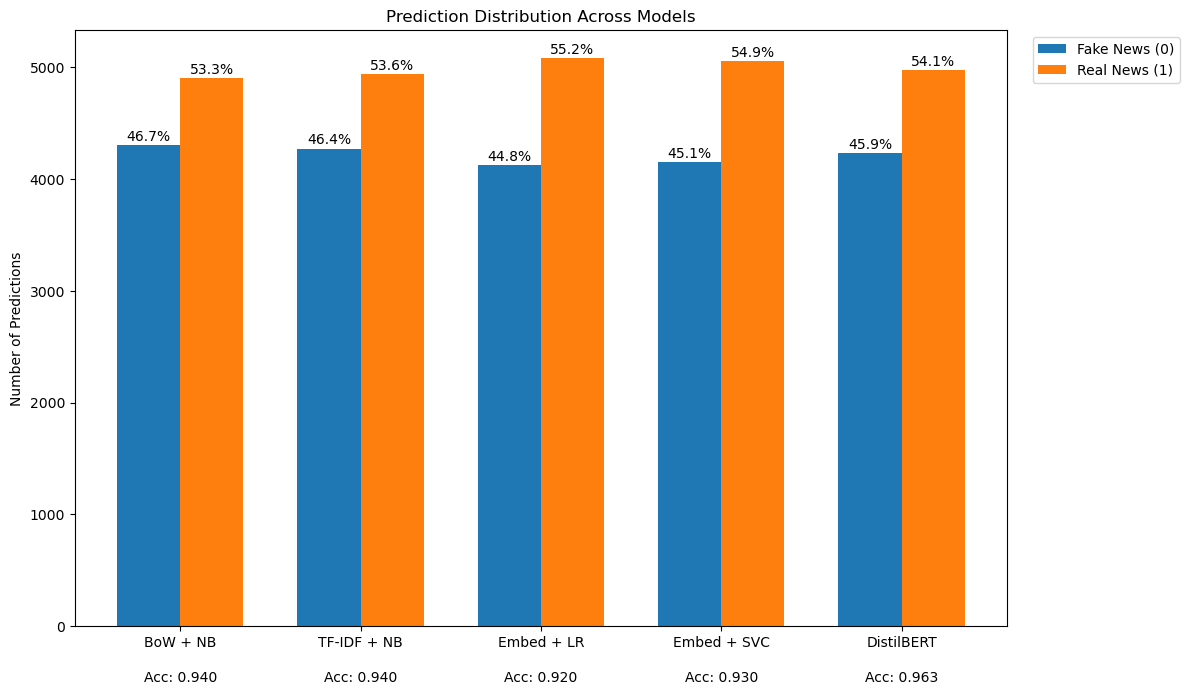

In [8]:
files = {
    "BoW + NB": bow_df,
    "TF-IDF + NB": tfidf_df,
    "Embed + LR": embed_lr_df,
    "Embed + SVC": embed_svc_df,
    "DistilBERT": distilbert_df
}


# Validation accuracies from training
accuracies = {
    "BoW + NB": 0.94,
    "TF-IDF + NB": 0.94,
    "Embed + LR": 0.92,
    "Embed + SVC": 0.93,
    "DistilBERT": 0.9626
}


# Lists for plotting
model_names = []
fake_counts = []
real_counts = []
fake_percentages = []
real_percentages = []


# Calculate counts and percentages
for model_name, df in files.items():

    counts = df['label'].value_counts().sort_index()

    fake_count = counts.get(0, 0)
    real_count = counts.get(1, 0)

    total = len(df)

    fake_percent = (fake_count / total) * 100
    real_percent = (real_count / total) * 100

    model_names.append(model_name)

    fake_counts.append(fake_count)
    real_counts.append(real_count)

    fake_percentages.append(fake_percent)
    real_percentages.append(real_percent)


# ============================================
# PLOT
# ============================================

x = np.arange(len(model_names))
width = 0.35

plt.figure(figsize=(12,7))

bars1 = plt.bar(
    x - width/2,
    fake_counts,
    width,
    label='Fake News (0)'
)

bars2 = plt.bar(
    x + width/2,
    real_counts,
    width,
    label='Real News (1)'
)


# Add percentage labels above bars
for i, bar in enumerate(bars1):

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 40,
        f"{fake_percentages[i]:.1f}%",
        ha='center'
    )


for i, bar in enumerate(bars2):

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 40,
        f"{real_percentages[i]:.1f}%",
        ha='center'
    )


# Add accuracy below x-axis
for i, model in enumerate(model_names):

    plt.text(
        x[i],
        -500,
        f"Acc: {accuracies[model]:.3f}",
        ha='center',
        fontsize=10
    )


plt.xticks(x, model_names)
plt.ylabel("Number of Predictions")
plt.title("Prediction Distribution Across Models")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()

plt.show()